In [1]:

import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from glob import glob
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_score, recall_score, f1_score,
                             accuracy_score, jaccard_score)

import seaborn as sns
import tensorflow as tf
from tensorflow.keras.utils import Sequence
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Conv2DTranspose, 
                                     concatenate, Input, Add, BatchNormalization, Activation)
from tensorflow.keras.layers import LayerNormalization, Dense, Reshape, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# ⚙️ Config
IMAGE_SIZE = 256
BATCH_SIZE = 8
EPOCHS = 25

2026-04-12 17:09:27.103876: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776013767.309807      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776013767.375667      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776013767.817776      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776013767.817816      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776013767.817819      55 computation_placer.cc:177] computation placer alr

In [2]:

train_image_path = "/kaggle/input/datasets/niyarrbarman/landslide-divided/dataset/train/images"
train_mask_path = "/kaggle/input/datasets/niyarrbarman/landslide-divided/dataset/train/masks"
val_image_path = "/kaggle/input/datasets/niyarrbarman/landslide-divided/dataset/validation/images"
val_mask_path = "/kaggle/input/datasets/niyarrbarman/landslide-divided/dataset/validation/masks"
test_image_path = "/kaggle/input/datasets/niyarrbarman/landslide-divided/dataset/test/images"
test_mask_path = "/kaggle/input/datasets/niyarrbarman/landslide-divided/dataset/test/masks"


In [3]:

def read_image(path):
    image = cv2.imread(path, cv2.IMREAD_COLOR)
    image = cv2.resize(image, (IMAGE_SIZE, IMAGE_SIZE))
    image = image / 255.0
    return image

def read_mask(path):
    mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (IMAGE_SIZE, IMAGE_SIZE))
    mask = np.expand_dims(mask, axis=-1)
    mask = mask / 255.0
    return mask


In [4]:

class DataGenerator(Sequence):
    def __init__(self, image_paths, mask_paths, batch_size=BATCH_SIZE, shuffle=True):
        super().__init__()
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.image_paths) / self.batch_size))  # ✅ FIXED

    def on_epoch_end(self):
        self.indices = np.arange(len(self.image_paths))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __getitem__(self, index):
        indices = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        batch_images = [read_image(self.image_paths[i]) for i in indices]
        batch_masks = [read_mask(self.mask_paths[i]) for i in indices]
        return np.array(batch_images), np.array(batch_masks)

In [15]:

def mobilevit_block(x, filters):

    # Local representation
    y = Conv2D(filters, 3, padding="same", activation="relu")(x)
    y = BatchNormalization()(y)


    h, w, c = y.shape[1], y.shape[2], y.shape[3]

    # Flatten
    y_flat = Reshape((h * w, c))(y)

    attn = tf.keras.layers.MultiHeadAttention(
        num_heads=1, key_dim=c)(y_flat, y_flat)

    y_flat = Add()([y_flat, attn])
    y_flat = LayerNormalization()(y_flat)

    # Feed-forward
    ffn = Dense(c * 2, activation="relu")(y_flat)
    ffn = Dense(c)(ffn)

    y_flat = Add()([y_flat, ffn])
    y_flat = LayerNormalization()(y_flat)

    y = Reshape((h, w, c))(y_flat)

    # Fusion 
    y = Conv2D(filters, 1, padding="same", activation="relu")(y)
    y = Add()([x, y])

    return y

def conv_block(x, filters):
    x = Conv2D(filters, 3, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = Conv2D(filters, 3, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    return x

def build_mobilevit_unet(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)):
    inputs = Input(shape=input_shape)
    # Encoder
    c1 = conv_block(inputs, 64)
    p1 = MaxPooling2D()(c1)
    c2 = conv_block(p1, 128)
    p2 = MaxPooling2D()(c2)
    c3 = conv_block(p2, 256)
    p3 = MaxPooling2D()(c3)
    c4 = conv_block(p3, 256)   
    p4 = MaxPooling2D()(c4)
    # Bottleneck 
    b = conv_block(p4, 256)
    b = mobilevit_block(b, 256)
    # Decoder
    u1 = Conv2DTranspose(256, 2, strides=2, padding="same")(b)
    u1 = concatenate([u1, c4])
    c5 = conv_block(u1, 256)
    u2 = Conv2DTranspose(256, 2, strides=2, padding="same")(c5)
    u2 = concatenate([u2, c3])
    c6 = conv_block(u2, 256)
    u3 = Conv2DTranspose(128, 2, strides=2, padding="same")(c6)
    u3 = concatenate([u3, c2])
    c7 = conv_block(u3, 128)
    u4 = Conv2DTranspose(64, 2, strides=2, padding="same")(c7)
    u4 = concatenate([u4, c1])
    c8 = conv_block(u4, 64)
    # Output
    outputs = Conv2D(1, 1, activation="sigmoid")(c8)
    return Model(inputs, outputs, name="MobileViT_UNet")

In [16]:


train_images = sorted(glob(os.path.join(train_image_path + "/*")))
train_masks = sorted(glob(os.path.join(train_mask_path + "/*")))
val_images = sorted(glob(os.path.join(val_image_path + "/*")))
val_masks = sorted(glob(os.path.join(val_mask_path + "/*")))

train_gen = DataGenerator(train_images, train_masks)
val_gen = DataGenerator(val_images, val_masks)

In [17]:
print("Train images:", len(train_images))
print("Val images:", len(val_images))

Train images: 1385
Val images: 396


In [18]:
model = build_mobilevit_unet()

model.compile(
    optimizer=Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [19]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint("model.keras", save_best_only=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3, verbose=1),
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, verbose=1)
]

history = model.fit(train_gen, validation_data=val_gen, epochs=EPOCHS, callbacks=callbacks)


Epoch 1/25
174/174 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 0.8934 - loss: 0.3708

2026-04-12 18:31:16.580826: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 18:31:16.837573: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_loss improved from inf to 0.24947, saving model to model.keras
174/174 ━━━━━━━━━━━━━━━━━━━━ 92s 318ms/step - accuracy: 0.8936 - loss: 0.3702 - val_accuracy: 0.9493 - val_loss: 0.2495 - learning_rate: 1.0000e-04
Epoch 2/25
174/174 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.9499 - loss: 0.1580
Epoch 2: val_loss improved from 0.24947 to 0.17364, saving model to model.keras
174/174 ━━━━━━━━━━━━━━━━━━━━ 34s 195ms/step - accuracy: 0.9499 - loss: 0.1579 - val_accuracy: 0.9493 - val_loss: 0.1736 - learning_rate: 1.0000e-04
Epoch 3/25
174/174 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.9496 - loss: 0.1382
Epoch 3: val_loss improved from 0.17364 to 0.12614, saving model to model.keras
174/174 ━━━━━━━━━━━━━━━━━━━━ 34s 195ms/step - accuracy: 0.9496 - loss: 0.1381 - val_accuracy: 0.9509 - val_loss: 0.1261 - learning_rate: 1.0000e-04
Epoch 4/25
174/174 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.9493 - loss: 0.1250
Epoch 4: val_loss improved from 0.12614 to 0.10360, sav

In [20]:
model.summary()

Model: "MobileViT_UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_31 (Conv2D)  │ (None, 256, 256,  │      1,792 │ input_layer_2[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_31[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_21       │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_32 (Conv2D)  │ (None, 256, 256,  │     36,928 │ activation_21[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_32[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_22       │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 128, 128,  │          0 │ activation_22[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_33 (Conv2D)  │ (None, 128, 128,  │     73,856 │ max_pooling2d_4[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_33[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_23       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_34 (Conv2D)  │ (None, 128, 128,  │    147,584 │ activation_23[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_34[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_24       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 64, 64,    │          0 │ activation_24[0]… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_35 (Conv2D)  │ (None, 64, 64,    │    295,168 │ max_pooling2d_5[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │      1,024 │ conv2d_35[0][0] 

 Total params: 28,441,413 (108.50 MB)

 Trainable params: 9,478,081 (36.16 MB)

 Non-trainable params: 7,168 (28.00 KB)

 Optimizer params: 18,956,164 (72.31 MB)

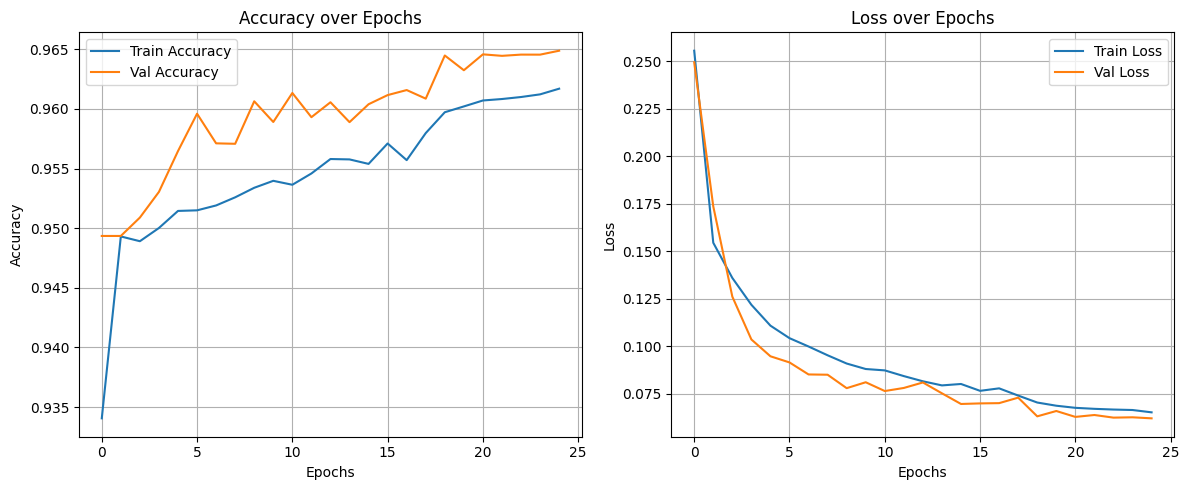

In [21]:

plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy over Epochs")
plt.legend()
plt.grid()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss over Epochs")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


In [22]:

test_images = sorted(glob(os.path.join(test_image_path, "*.png")))
test_masks = sorted(glob(os.path.join(test_mask_path, "*.png")))
test_gen = DataGenerator(test_images, test_masks, shuffle=False)

train_loss, train_acc = model.evaluate(train_gen, verbose=0)
test_loss, test_acc = model.evaluate(test_gen, verbose=0)

print(f"✅ Final Training Accuracy: {train_acc*100:.2f}%")
print(f"✅ Final Testing Accuracy : {test_acc*100:.2f}%")


2026-04-12 18:45:49.719064: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 18:45:49.952900: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 18:45:50.571571: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 18:45:50.828488: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


✅ Final Training Accuracy: 96.32%
✅ Final Testing Accuracy : 95.86%


In [23]:

y_true, y_pred = [], []

for i in range(len(test_gen)):
    X_batch, Y_batch = test_gen[i]
    preds = model.predict(X_batch)
    preds = (preds > 0.5).astype(np.uint8).flatten()
    Y_batch = (Y_batch > 0.5).astype(np.uint8).flatten()
    y_pred.extend(preds)
    y_true.extend(Y_batch)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=["No Landslide", "Landslide"]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

📊 Classification Report:
              precision    r

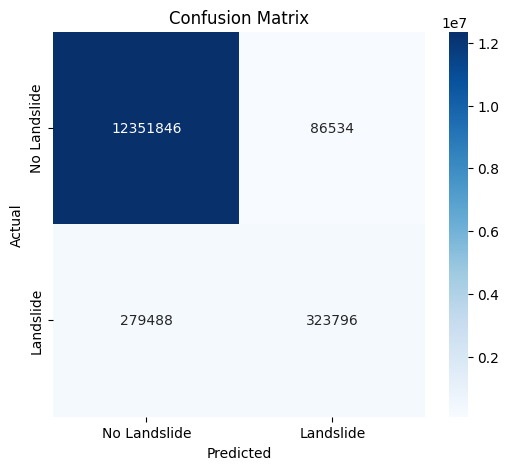

In [24]:

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["No Landslide", "Landslide"],
            yticklabels=["No Landslide", "Landslide"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [25]:

def dice_coef(y_true, y_pred):
    intersection = np.sum(y_true * y_pred)
    return (2. * intersection) / (np.sum(y_true) + np.sum(y_pred) + 1e-7)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
iou = jaccard_score(y_true, y_pred)
dice = dice_coef(y_true, y_pred)

print("\n📈 Pixel-wise Evaluation Metrics:")
print(f"Accuracy        : {accuracy:.4f}")
print(f"Precision       : {precision:.4f}")
print(f"Recall          : {recall:.4f}")
print(f"F1 Score        : {f1:.4f}")
print(f"IoU Score       : {iou:.4f}")
print(f"Dice Coefficient: {dice:.4f}")



📈 Pixel-wise Evaluation Metrics:
Accuracy        : 0.9719
Precision       : 0.7891
Recall          : 0.5367
F1 Score        : 0.6389
IoU Score       : 0.4694
Dice Coefficient: 0.6389


In [26]:
def calculate_area(mask):
    return np.sum(mask == 1)

def classify_severity(area):
    if area < 5000:
        return "Low"
    elif area < 20000:
        return "Medium"
    else:
        return "High"

def generate_heatmap(image, mask):
    heatmap = np.zeros_like(image)
    heatmap[:, :, 0] = mask.squeeze() * 255

    overlay = cv2.addWeighted(image.astype(np.float32), 0.7,
                              heatmap.astype(np.float32), 0.3, 0)
    return overlay

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


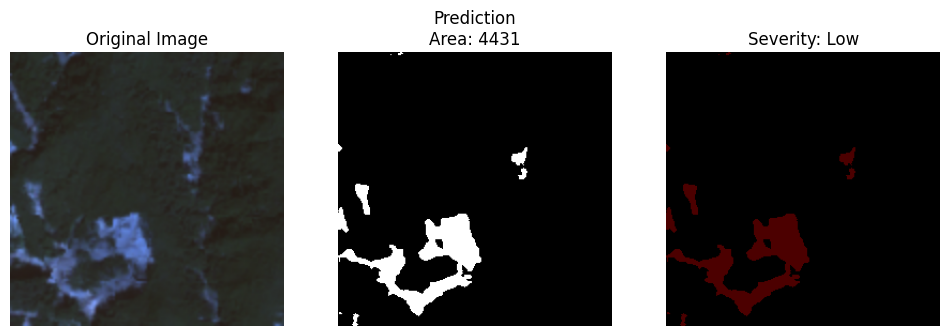

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


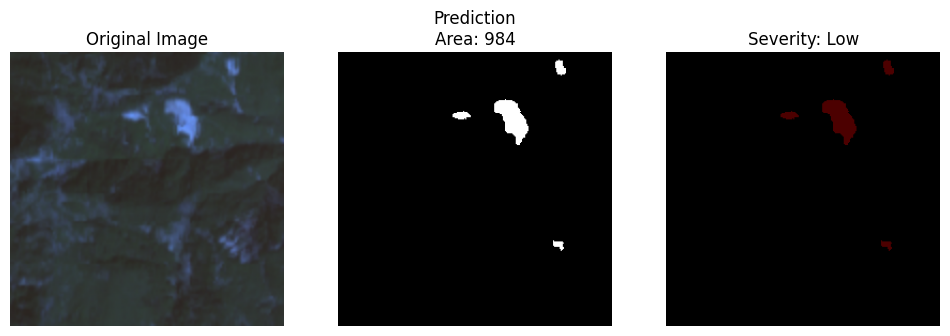

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


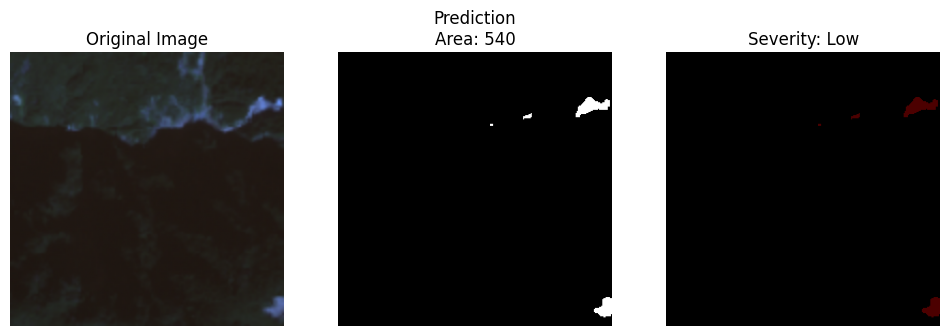

In [27]:

for i in range(3):   # show 3 samples
    img = read_image(test_images[i])
    mask = read_mask(test_masks[i])

    pred = model.predict(np.expand_dims(img, axis=0))[0]
    pred = (pred > 0.5).astype(np.uint8)

    # Area
    area = calculate_area(pred)

    # Severity
    severity = classify_severity(area)

    # Heatmap
    heatmap = generate_heatmap(img, pred)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.title("Original Image")
    plt.imshow(img)
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title(f"Prediction\nArea: {area}")
    plt.imshow(pred.squeeze(), cmap='gray')
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.title(f"Severity: {severity}")
    plt.imshow(heatmap.astype(np.uint8))
    plt.axis("off")

    plt.show()